# EpiMask Match Demo

Loads a released EpiMask checkpoint, runs inference on one SatDepth image pair, and visualizes the result: 2D match overlay, an interactive 3D (ECEF) point cloud of matched points, per-layer self/cross-attention maps, and model FLOPs/params.

**Assumes this notebook's working directory is `notebook/`** (the default when opening it directly in Jupyter/VSCode) so that `PROJECT_DIR` below resolves to the repo root.

**Prerequisites** (see README "Demo" for the full quickstart): `external/{LoFTR,satdepth,satlaspretrain}` set up via `scripts/setup_external/*.sh`, a checkpoint downloaded under `model_weights/` matching `exp_name`/`ckpt_filename` in `epimask_demo.yaml`, and the demo shard downloaded and placed at `data/satdepth/webdataset/satdepth-demo/` (or the full `data/satdepth/webdataset/` set up per "Setup SatDepth Dataset" -- see `shard_subdir` in `epimask_demo.yaml`).

## 1. Path setup

In [1]:
import os
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent  # notebook/ -> repo root

# Mirrors the PYTHONPATH convention used by scripts/epimask/*.sh:
# - PROJECT_DIR.parent so `epimask.*` absolute imports resolve
# - external/ so `satdepth.*` (vendored) self-imports resolve
# - external/satlaspretrain so satlaspretrain_models self-imports resolve
for p in [PROJECT_DIR.parent, PROJECT_DIR / "external", PROJECT_DIR / "external" / "satlaspretrain"]:
    p = str(p)
    if p not in sys.path:
        sys.path.insert(0, p)


In [2]:
import yaml
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib
from skimage import exposure
from skimage.transform import resize

from epimask.src.config.epimask_default import get_cfg
from epimask.src.model.epimask import EpiMask
from epimask.src.model.epimask_module.transformer import MaskedXAttentionLayer
from epimask.src.model.epimask_module.epipolar_geometry import (
    Calculate_Epipolar_Distance,
    make_2d_coordinates,
)
from epimask.src.datasets.satdepth_webdataset import ShardedSatDepthDataset
from epimask.src.utils import sat_metrics
from epimask.src.utils.sat_plotting import make_matching_figure, error_colormap, dynamic_alpha
from epimask.external.LoFTR.src.loftr.loftr_module.linear_attention import LinearAttention
import epimask.external.satdepth.src.model.utils.sat_supervision as sat_supervision


/mnt/cloudNAS4/aditya/anaconda3/envs/smart_py38_torch/lib/python3.8/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


## 2. Load demo config + model config

In [3]:
with open("epimask_demo.yaml") as f:
    cfg = yaml.safe_load(f)

exp_dir = PROJECT_DIR / "model_weights" / cfg["exp_name"]
model_config = get_cfg(str(exp_dir / "train_config.yaml"))
model_config["epimask"]["match_coarse"]["thr"] = cfg["match_thr"]

coarse_scale = model_config["epimask"]["resolution"][0]

# exp_dir also keeps the original raw checkpoint (untouched, for provenance / re-running
# model_weights/remove_calc_fest_weights.py) - ckpt_filename names the cleaned one to load.
ckpt_path = exp_dir / cfg["ckpt_filename"]
assert ckpt_path.exists(), f"checkpoint not found: {ckpt_path}"
print("checkpoint:", ckpt_path)


checkpoint: /mnt/cloudNAS2/rahul/MyGitRepos/epimask/model_weights/epimask-HR-gamma-pt4-lora32-stage2/epimask-HR-gamma-pt4-lora32-stage2.ckpt


## 3. Build model + register attention hooks + load checkpoint

In [4]:
attn_maps = {}

def cross_attn_hook(module, inputs, output):
    full_name = module._name          # e.g. "coarse_transformer.layers.1.attn"
    epi_thr = module._epi_dist_thr
    attn_maps.setdefault(full_name, []).append({
        "attn": output.detach().cpu().clone(),
        "epi_dist_thr": epi_thr,
    })

def self_attn_feature_hook(module, inputs, output):
    # inputs = (queries, keys, values, q_mask, kv_mask)
    queries, keys = inputs[0], inputs[1]
    Q = module.feature_map(queries).detach()
    K = module.feature_map(keys).detach()
    attn = torch.einsum("nlhd,nshd->nhls", Q, K).cpu()
    attn_maps.setdefault(module._name, []).append({"attn": attn})

def register_attention_hooks(model):
    for name, module in model.named_modules():
        if isinstance(module, MaskedXAttentionLayer) and "coarse_transformer" in name:
            module.softmax._name = f"{name}.cross_attn"
            module.softmax._epi_dist_thr = float(module.epi_dist_thr)
            module.softmax.register_forward_hook(cross_attn_hook)
        elif isinstance(module, LinearAttention) and "coarse_transformer" in name:
            module._name = f"{name}.self_attn"
            module.register_forward_hook(self_attn_feature_hook)


In [5]:
model = EpiMask(config=model_config["epimask"])
model.apply_epipolar_dist_thr_decay()
register_attention_hooks(model)

state_dict = torch.load(ckpt_path, map_location="cpu")["state_dict"]
load_result = model.load_state_dict(state_dict, strict=False)
assert not load_result.missing_keys, f"missing keys the model needs: {load_result.missing_keys}"
if load_result.unexpected_keys:
    print("skipped unexpected checkpoint keys:", load_result.unexpected_keys)

device = f"cuda:{cfg['device']}" if (cfg["device"] is not None and torch.cuda.is_available()) else "cpu"
print("using device:", device)
model.to(device)
model.eval()


USING FPN_FUSION_TYPE CONCAT_CONV


/mnt/cloudNAS2/rahul/MyGitRepos/epimask/external/satlaspretrain/satlaspretrain_models/model.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(weights

Applying decay to epipolar distance threshold: [168.0, 134.4, 100.8, 67.19999999999999]


/tmp/ipykernel_12037/1252934358.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_location="cpu")["state_dict"]


using device: cuda:0


EpiMask(
  (backbone): SatlasFPN_4_2_v3(
    (satlas_encoder): SatlasBackbone(
      (backbone): PeftModelForFeatureExtraction(
        (base_model): LoraModel(
          (model): Model(
            (backbone): SwinBackbone(
              (backbone): SwinTransformer(
                (features): Sequential(
                  (0): Sequential(
                    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
                    (1): Permute()
                    (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
                  )
                  (1): Sequential(
                    (0): SwinTransformerBlockV2(
                      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
                      (attn): ShiftedWindowAttentionV2(
                        (qkv): lora.Linear(
                          (base_layer): Linear(in_features=128, out_features=384, bias=True)
                          (lora_dropout): ModuleDict(
                            (def

## 4. Load one data sample

In [6]:
shard_dir = PROJECT_DIR / "data" / "satdepth" / "webdataset" / cfg["shard_subdir"]

test_dataset = ShardedSatDepthDataset(
    shard_dir=str(shard_dir),
    shard_size=cfg["shard_size_val"],
    phase="val",
    world_size=1,
    shuffle_buffer_size=None,
)
test_dataloader = DataLoader(test_dataset, batch_size=1, num_workers=1, pin_memory=False, shuffle=False)


def get_nth_batch(dataloader, n):
    """ShardedSatDepthDataset is an IterableDataset (no random access) -
    deterministically scan to the n-th batch."""
    for i, batch in enumerate(dataloader):
        if i == n:
            return batch
    raise IndexError(f"dataloader exhausted before reaching sample_idx={n}")


data = get_nth_batch(test_dataloader, cfg["sample_idx"])
img0_np = data["image0"].numpy()[0]
img1_np = data["image1"].numpy()[0]

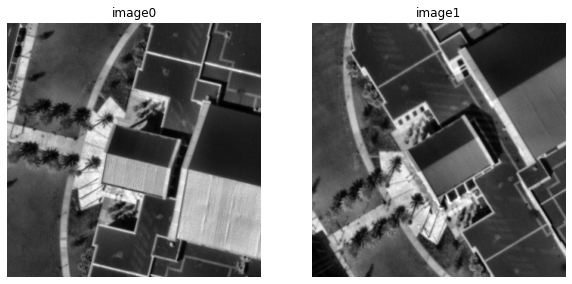

In [7]:
img0 = exposure.equalize_adapthist(np.transpose(img0_np, (1, 2, 0)))
img1 = exposure.equalize_adapthist(np.transpose(img1_np, (1, 2, 0)))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img0, cmap="gray"); axes[0].set_title("image0"); axes[0].axis("off")
axes[1].imshow(img1, cmap="gray"); axes[1].set_title("image1"); axes[1].axis("off")
plt.show()


## 5. Run inference

In [8]:
for key in ["image0", "image1", "lat0", "lon0", "ht0", "lat1", "lon1", "ht1",
            "affine_cam0", "affine_cam1", "F_gt"]:
    data[key] = data[key].to(device)

with torch.no_grad():
    model(data)

sat_supervision.coarse_supervision(data, model_config["epimask"])
sat_metrics.compute_distance_errors(data)
# compute_pose_errors mutates `data` in place (appends to data["phi_errs"]/["theta_errs"]/["s_errs"]), returns None
sat_metrics.compute_pose_errors(data, config=model_config["trainer"], nMatchesKeep=cfg["nMatchesKeep"])
print(f"pose error (deg) - phi: {np.mean(data['phi_errs']):.3f}  theta: {np.mean(data['theta_errs']):.3f}  scale: {np.mean(data['s_errs']):.3f}")


pose error (deg) - phi: 0.065  theta: 0.071  scale: 0.001


## 6. 2D match visualization

Uses the repo's own `sat_plotting.make_matching_figure` (the same coloring convention used for training/val visualization: `error_colormap` + `dynamic_alpha`), truncated to the top `nMatchesKeep` matches by confidence for readability.

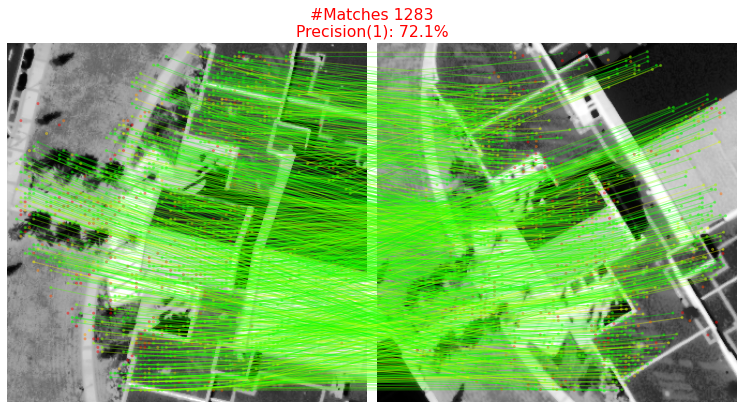

In [9]:
b_mask = data["m_bids"] == 0
mconf = data["mconf"][b_mask].cpu().numpy()
kpts0 = data["mkpts0_f"][b_mask].cpu().numpy()
kpts1 = data["mkpts1_f"][b_mask].cpu().numpy()
epi_errs = data["epi_errs"][b_mask].cpu().numpy()

order = np.argsort(mconf)[::-1][: cfg["nMatchesKeep"]]
kpts0, kpts1, epi_errs = kpts0[order], kpts1[order], epi_errs[order]

conf_thr = model_config["trainer"]["epipolar_thr"]
color = error_colormap(epi_errs, conf_thr, alpha=dynamic_alpha(len(kpts0)))
precision = (epi_errs < conf_thr).mean() * 100
text = [f"#Matches {len(kpts0)}", f"Precision({conf_thr:.2g}): {precision:.1f}%"]

img0_eq = exposure.equalize_hist(img0_np[0])
img1_eq = exposure.equalize_hist(img1_np[0])
fig = make_matching_figure(img0_eq, img1_eq, kpts0, kpts1, color, epi_errs, conf_thr, text=text)
plt.show()
plt.close(fig)



## 7. 3D point cloud (ECEF)

Matched keypoints' lat/lon/height projected into ECEF coordinates and colored by the left image's pixel value at each match.

In [10]:
import plotly.graph_objects as go


def latlonh_to_ecef(lat, lon, h):
    a = 6378137.0
    b = 6356752.314245
    lat_rad = lat * np.pi / 180.0
    lon_rad = lon * np.pi / 180.0
    N_lat = a**2 / np.sqrt((a**2) * np.cos(lat_rad) ** 2 + (b**2) * np.sin(lat_rad) ** 2)
    x = (N_lat + h) * np.cos(lat_rad) * np.cos(lon_rad)
    y = (N_lat + h) * np.cos(lat_rad) * np.sin(lon_rad)
    z = ((b**2) / (a**2) * N_lat + h) * np.sin(lat_rad)
    return x, y, z


def plot_3d_matches_interactive(img0, lat0, lon0, ht0, kpts0, epi_errs, show_bad=False):
    x0 = kpts0[:, 0].astype(int)
    y0 = kpts0[:, 1].astype(int)

    lats, lons, hts = lat0[y0, x0], lon0[y0, x0], ht0[y0, x0]
    x, y, z = latlonh_to_ecef(lats, lons, hts)
    x, y, z = x - x.mean(), y - y.mean(), z - z.mean()

    img0_rgb = np.stack([img0] * 3, axis=-1) if img0.ndim == 2 else img0
    good_mask = epi_errs < 1
    bad_mask = ~good_mask

    scatter_data = []
    if np.any(good_mask):
        good_colors = img0_rgb[y0[good_mask], x0[good_mask]] / 255.0
        good_colors_hex = [f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})" for r, g, b in good_colors]
        scatter_data.append(go.Scatter3d(
            x=x[good_mask], y=y[good_mask], z=z[good_mask],
            mode="markers", marker=dict(size=3, color=good_colors_hex), hoverinfo="skip",
        ))
    if show_bad and np.any(bad_mask):
        scatter_data.append(go.Scatter3d(
            x=x[bad_mask], y=y[bad_mask], z=z[bad_mask],
            mode="markers", marker=dict(size=3, color="red"), hoverinfo="skip",
        ))

    fig = go.Figure(data=scatter_data)
    fig.update_layout(
        scene=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False)),
        margin=dict(l=0, r=0, b=0, t=0),
        showlegend=False,
    )
    fig.show()


In [11]:
plot_3d_matches_interactive(
    img0_np[0],
    data["lat0"].cpu().numpy()[0],
    data["lon0"].cpu().numpy()[0],
    data["ht0"].cpu().numpy()[0],
    kpts0,
    epi_errs,
)


## 8. Self / masked cross-attention maps

In [12]:
calculate_epi_distance = Calculate_Epipolar_Distance().to(device)

hw0_i = np.array(img0_np[0].shape)
hw1_i = np.array(img1_np[0].shape)
h0_c, w0_c = hw0_i // coarse_scale
h1_c, w1_c = hw1_i // coarse_scale

x0, y0 = make_2d_coordinates(h0_c, w0_c, device=device)
x1, y1 = make_2d_coordinates(h1_c, w1_c, device=device)
x0, y0, x1, y1 = (t * coarse_scale for t in (x0, y0, x1, y1))

epi_dist = calculate_epi_distance(data["F_gt"], x0, y0, x1, y1)


In [13]:
def plot_cross_attn(xc, yc, left_image, right_image, attn_score, attn_mask, F_gt, num_att_pts=20):
    pad = 5
    H, W_left, W_right = left_image.shape[0], left_image.shape[1], right_image.shape[1]

    canvas = np.ones((H, W_left + pad + W_right), dtype=np.float32)
    canvas[:, :W_left] = left_image
    canvas[:, W_left + pad: W_left + pad + W_right] = right_image

    attn_mask_rgb = np.zeros((H, W_left + pad + W_right, 4), dtype=np.float32)
    right_offset = W_left + pad
    attn_mask_rgb[:, right_offset:right_offset + W_right][attn_mask] = [1.0, 0.0, 0.0, 0.5]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(canvas, cmap="gray")
    ax.imshow(attn_mask_rgb)
    ax.plot(xc, yc, "ro", markersize=20)

    # epipolar line for the query point
    l = F_gt[0, :, :].numpy() @ np.array([xc * coarse_scale, yc * coarse_scale, 1.0])
    a, b, c = l
    xs = np.linspace(0, W_right, 100)
    if abs(b) > 1e-8:
        ys = -((a * xs * coarse_scale + c) / b) / coarse_scale
        ax.plot(W_left + pad + xs, ys, "c", linewidth=1.5)
    else:
        x_interp = -c / a / coarse_scale
        ax.axvline(W_left + pad + x_interp, color="r", linewidth=1.5)

    flat = attn_score.reshape(-1)
    topk_idx = np.argpartition(flat, -num_att_pts)[-num_att_pts:]
    topk_idx = topk_idx[np.argsort(flat[topk_idx])[::-1]]
    ys_t, xs_t = np.unravel_index(topk_idx, attn_score.shape)
    for y_t, x_t in zip(ys_t, xs_t):
        ax.plot([xc, right_offset + x_t], [yc, y_t], linewidth=2)

    ax.set_xlim(0, W_left + pad + W_right)
    ax.set_ylim(0, H - 1)
    ax.axis("off")
    plt.show()
    plt.close(fig)


def plot_self_attn(xc, yc, left_image, attn_score, num_att_pts=20):
    H, W_left = left_image.shape[0], left_image.shape[1]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(left_image, cmap="gray")
    ax.plot(xc, yc, "ro", markersize=20)

    flat = attn_score.reshape(-1)
    topk_idx = np.argpartition(flat, -num_att_pts)[-num_att_pts:]
    topk_idx = topk_idx[np.argsort(flat[topk_idx])[::-1]]
    ys_t, xs_t = np.unravel_index(topk_idx, attn_score.shape)
    for y_t, x_t in zip(ys_t, xs_t):
        ax.plot([xc, x_t], [yc, y_t], linewidth=2)

    ax.axis("off")
    plt.show()
    plt.close(fig)


In [14]:
left_image = exposure.equalize_hist(resize(img0_np[0], (h0_c, w0_c), anti_aliasing=True))
right_image = exposure.equalize_hist(resize(img1_np[0], (h1_c, w1_c), anti_aliasing=True))

xc, yc = cfg["attn_query_point"]
num_att_pts = cfg["num_att_pts"]
idx = xc + w0_c * yc


self_attn layer 0 head 0


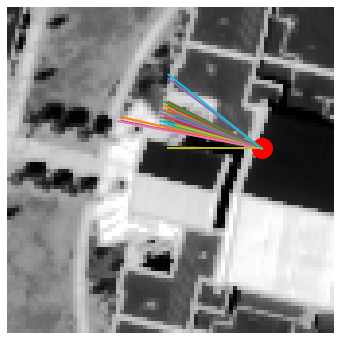

cross_attn layer 1 head 0 (epi_dist_thr=168.0)


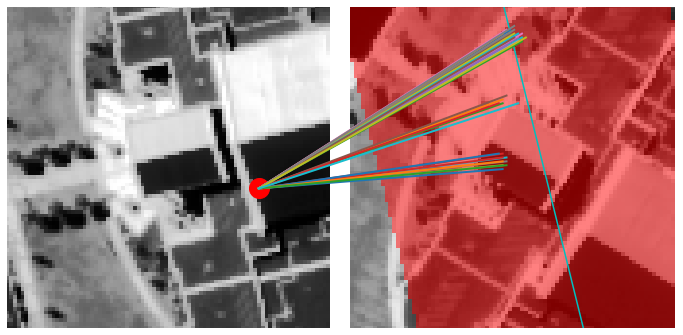

self_attn layer 2 head 0


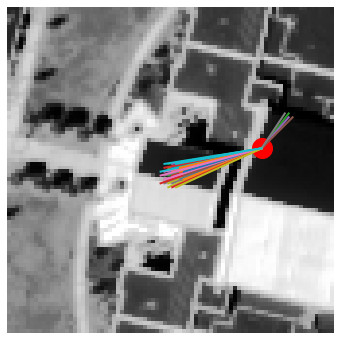

cross_attn layer 3 head 0 (epi_dist_thr=134.4)


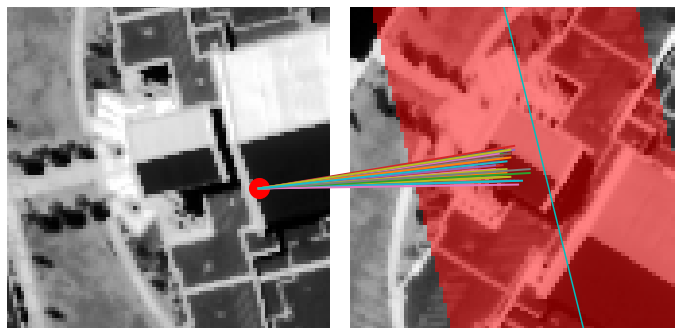

self_attn layer 4 head 0


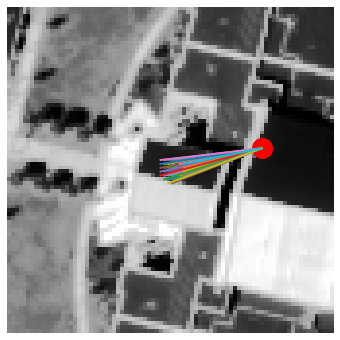

cross_attn layer 5 head 0 (epi_dist_thr=100.8)


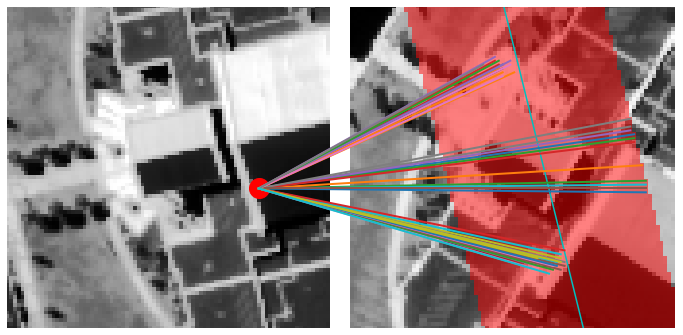

self_attn layer 6 head 0


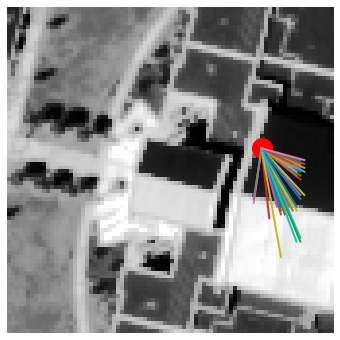

cross_attn layer 7 head 0 (epi_dist_thr=67.2)


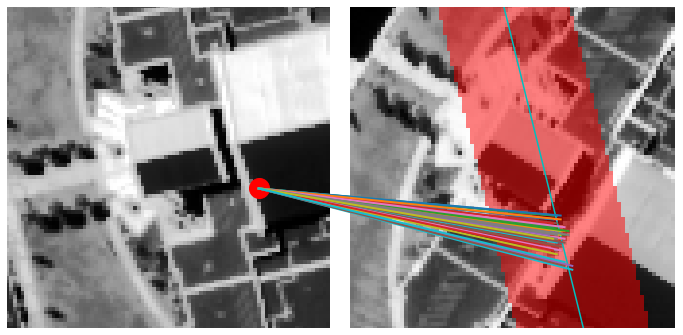

self_attn layer 0 head 1


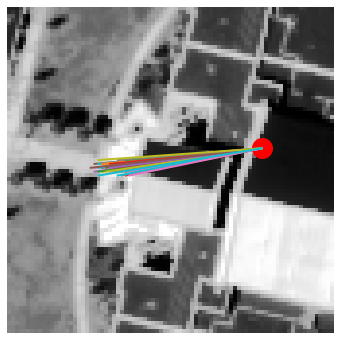

cross_attn layer 1 head 1 (epi_dist_thr=168.0)


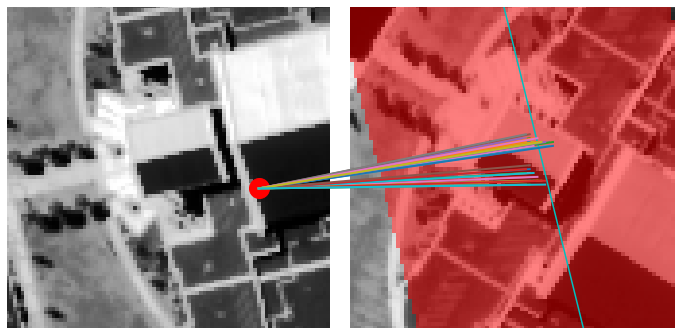

self_attn layer 2 head 1


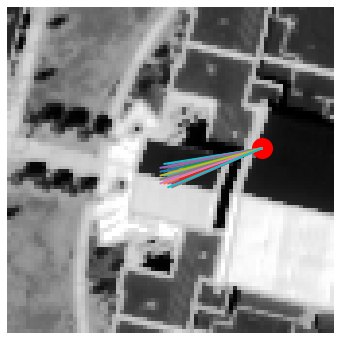

cross_attn layer 3 head 1 (epi_dist_thr=134.4)


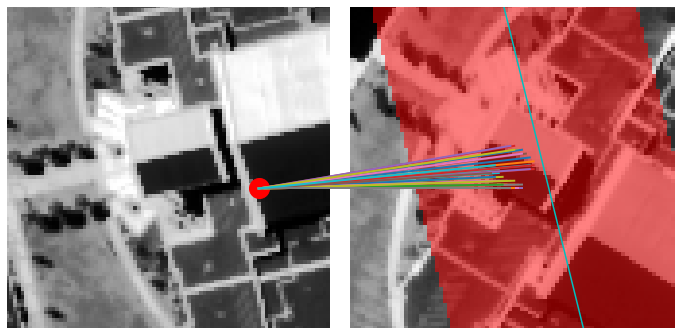

self_attn layer 4 head 1


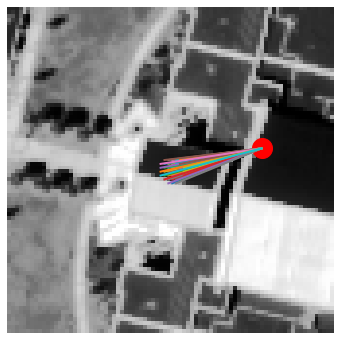

cross_attn layer 5 head 1 (epi_dist_thr=100.8)


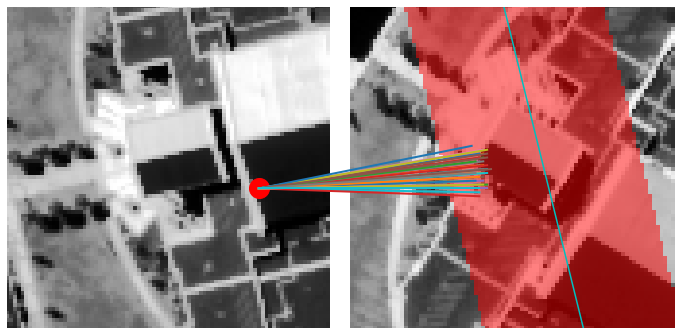

self_attn layer 6 head 1


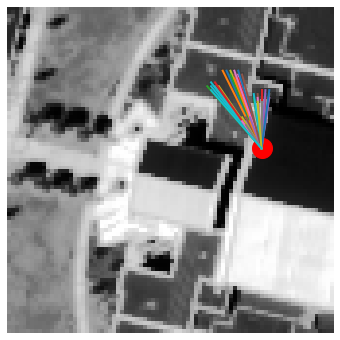

cross_attn layer 7 head 1 (epi_dist_thr=67.2)


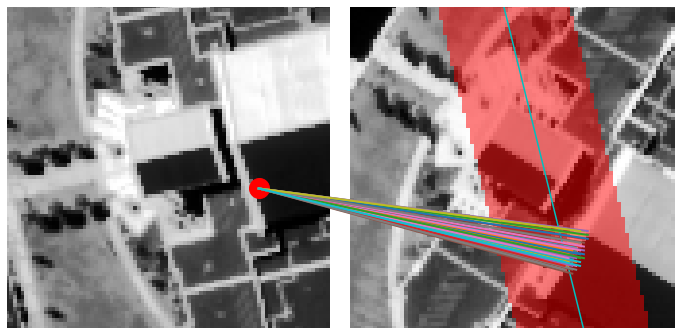

self_attn layer 0 head 2


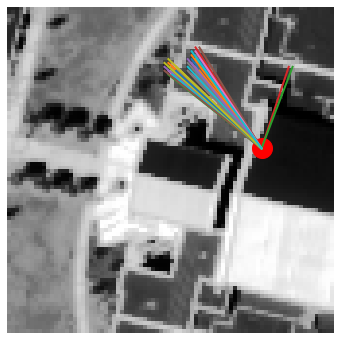

cross_attn layer 1 head 2 (epi_dist_thr=168.0)


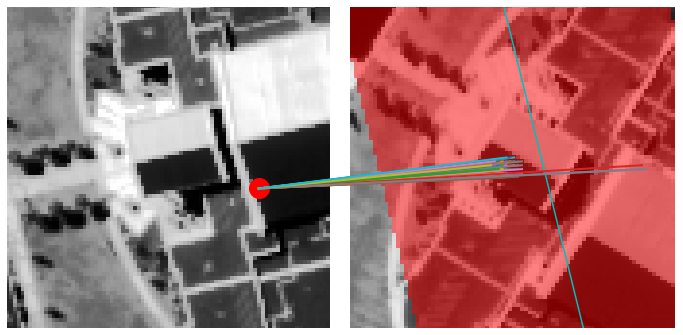

self_attn layer 2 head 2


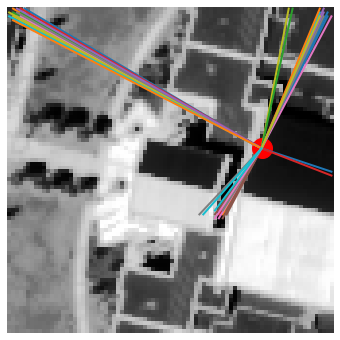

cross_attn layer 3 head 2 (epi_dist_thr=134.4)


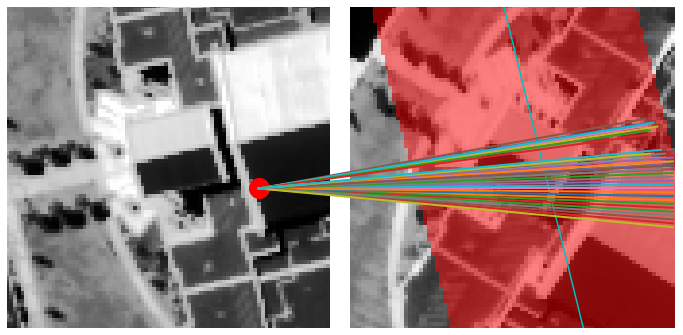

self_attn layer 4 head 2


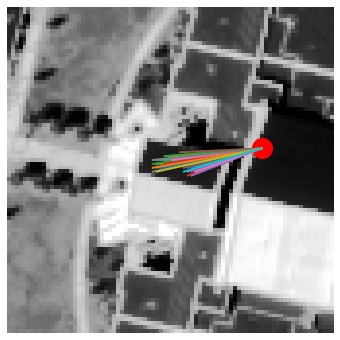

cross_attn layer 5 head 2 (epi_dist_thr=100.8)


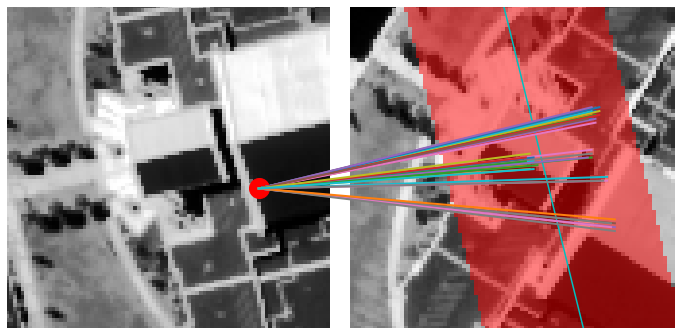

self_attn layer 6 head 2


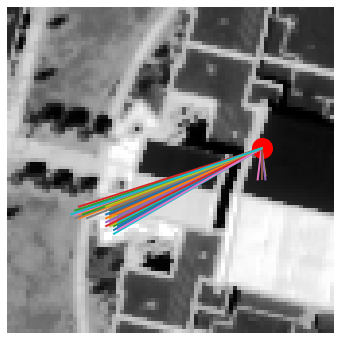

cross_attn layer 7 head 2 (epi_dist_thr=67.2)


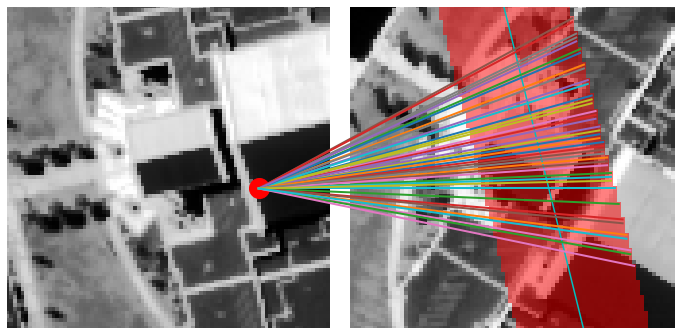

self_attn layer 0 head 3


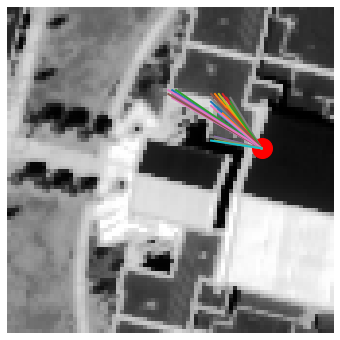

cross_attn layer 1 head 3 (epi_dist_thr=168.0)


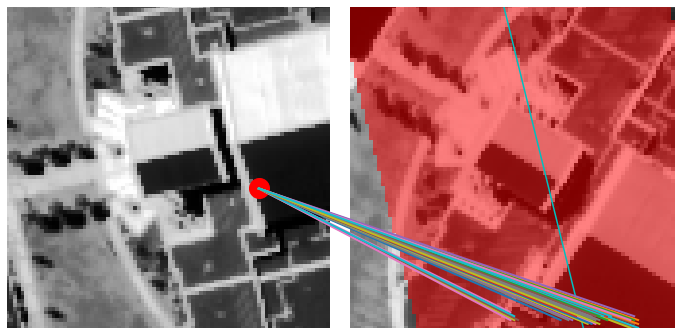

self_attn layer 2 head 3


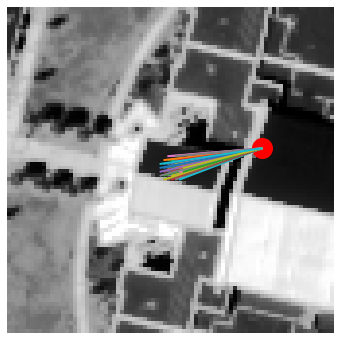

cross_attn layer 3 head 3 (epi_dist_thr=134.4)


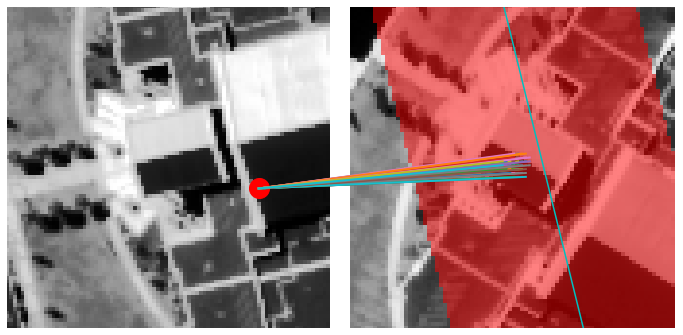

self_attn layer 4 head 3


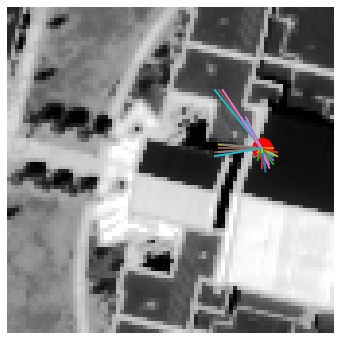

cross_attn layer 5 head 3 (epi_dist_thr=100.8)


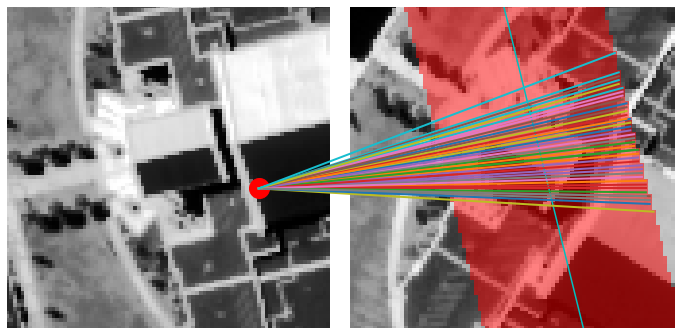

self_attn layer 6 head 3


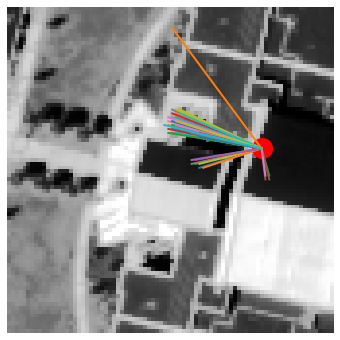

cross_attn layer 7 head 3 (epi_dist_thr=67.2)


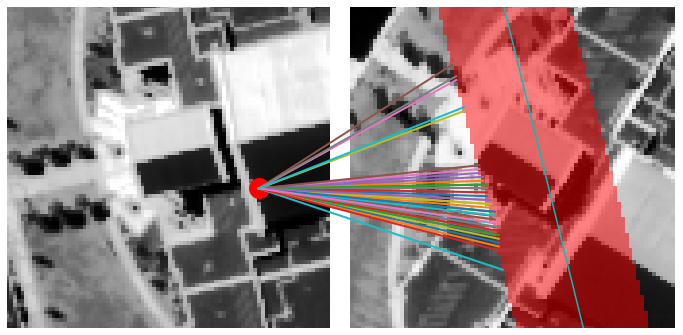

self_attn layer 0 head 4


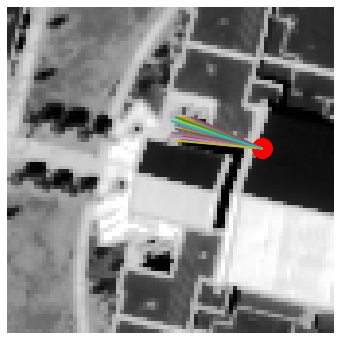

cross_attn layer 1 head 4 (epi_dist_thr=168.0)


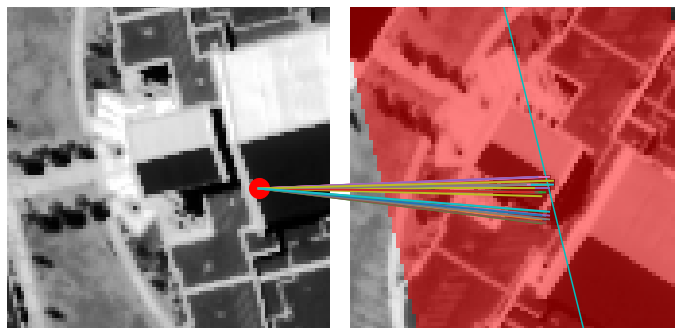

self_attn layer 2 head 4


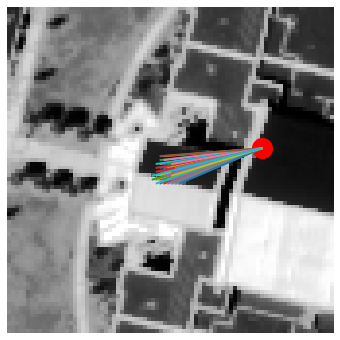

cross_attn layer 3 head 4 (epi_dist_thr=134.4)


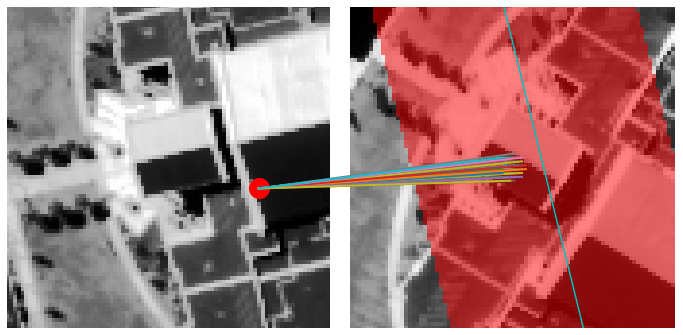

self_attn layer 4 head 4


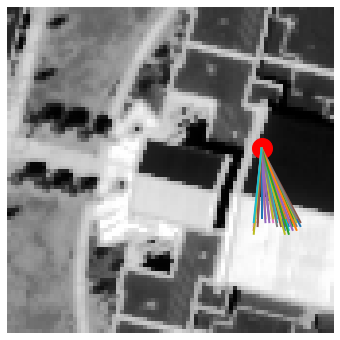

cross_attn layer 5 head 4 (epi_dist_thr=100.8)


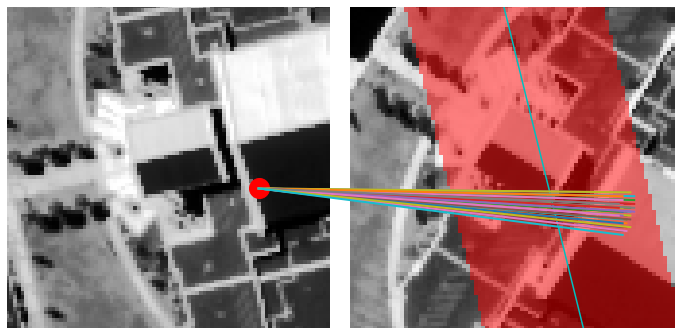

self_attn layer 6 head 4


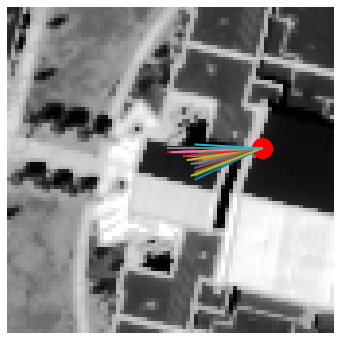

cross_attn layer 7 head 4 (epi_dist_thr=67.2)


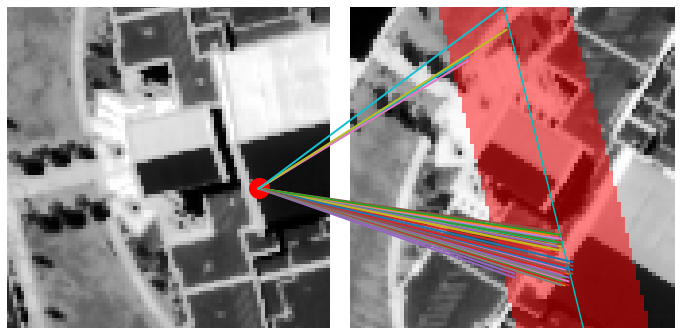

self_attn layer 0 head 5


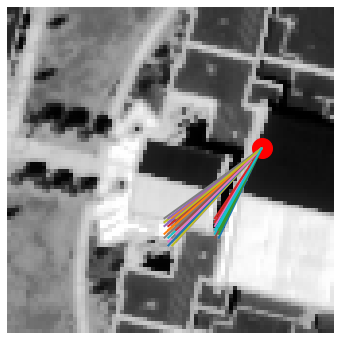

cross_attn layer 1 head 5 (epi_dist_thr=168.0)


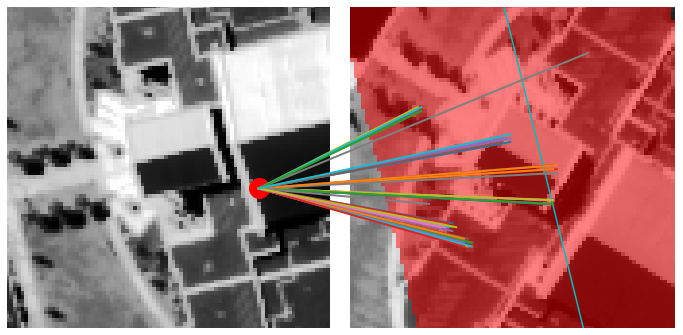

self_attn layer 2 head 5


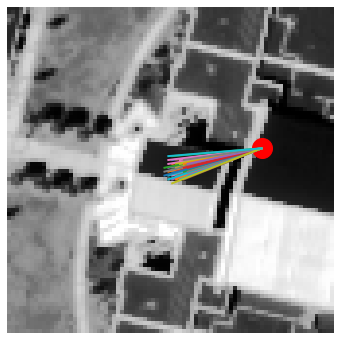

cross_attn layer 3 head 5 (epi_dist_thr=134.4)


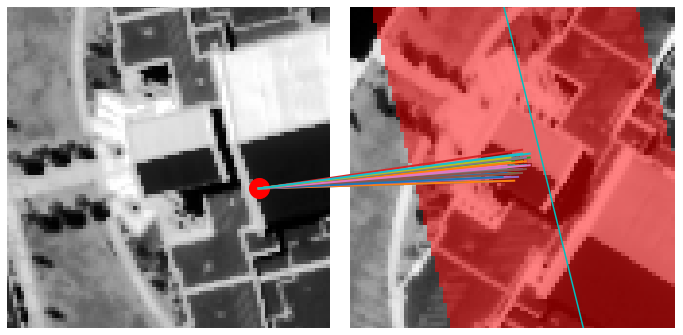

self_attn layer 4 head 5


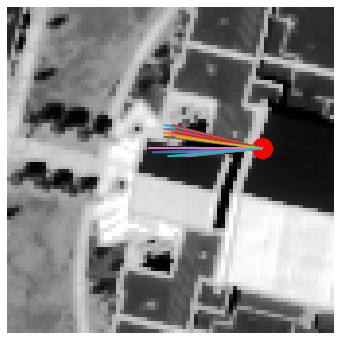

cross_attn layer 5 head 5 (epi_dist_thr=100.8)


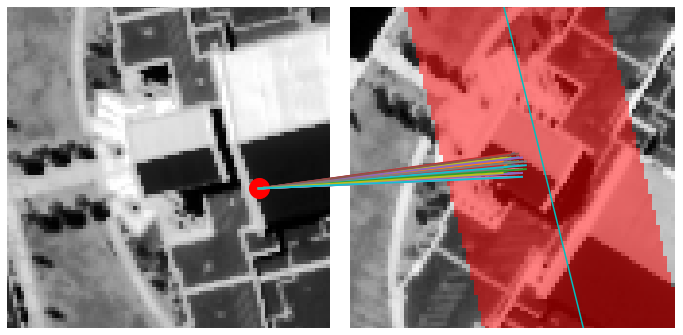

self_attn layer 6 head 5


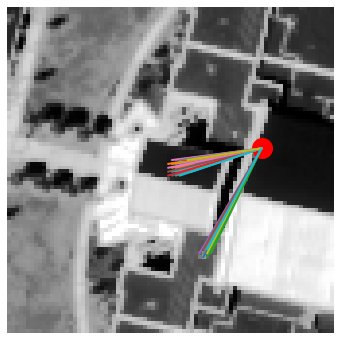

cross_attn layer 7 head 5 (epi_dist_thr=67.2)


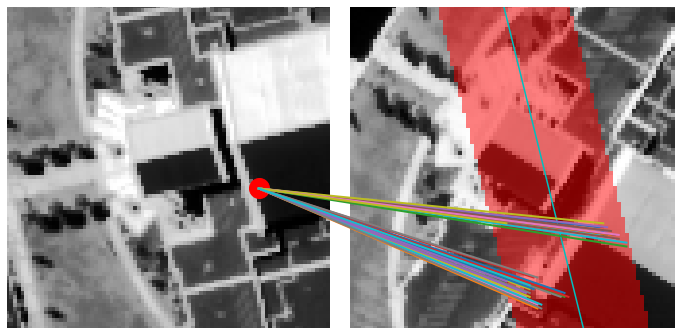

self_attn layer 0 head 6


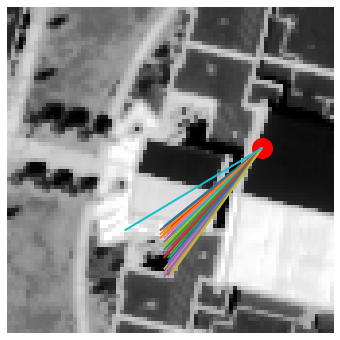

cross_attn layer 1 head 6 (epi_dist_thr=168.0)


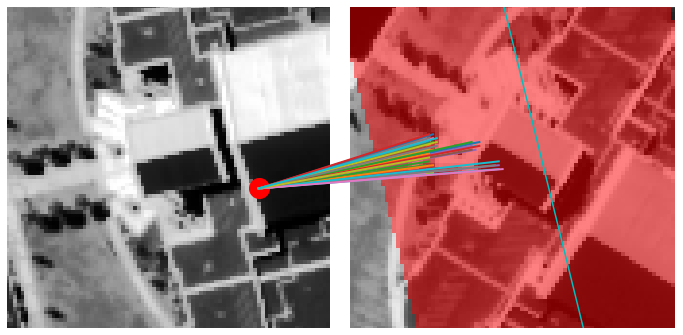

self_attn layer 2 head 6


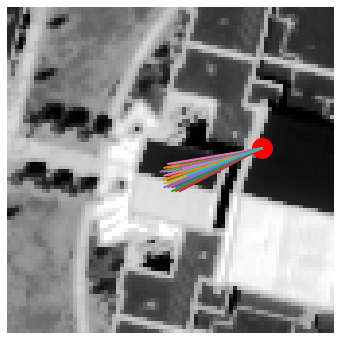

cross_attn layer 3 head 6 (epi_dist_thr=134.4)


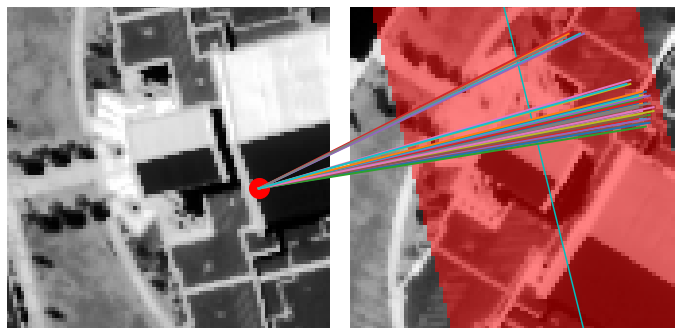

self_attn layer 4 head 6


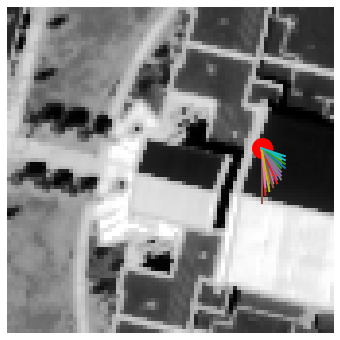

cross_attn layer 5 head 6 (epi_dist_thr=100.8)


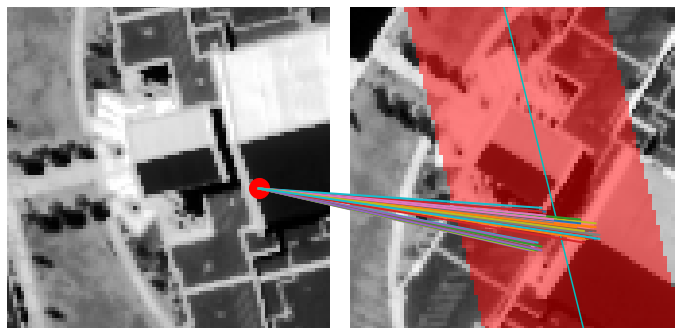

self_attn layer 6 head 6


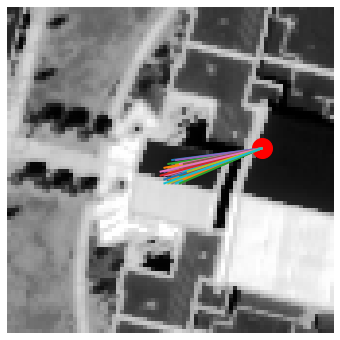

cross_attn layer 7 head 6 (epi_dist_thr=67.2)


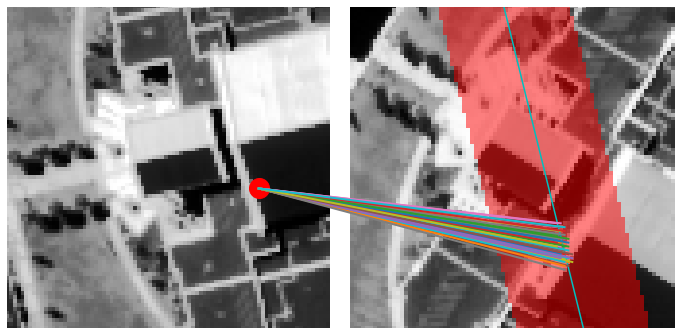

self_attn layer 0 head 7


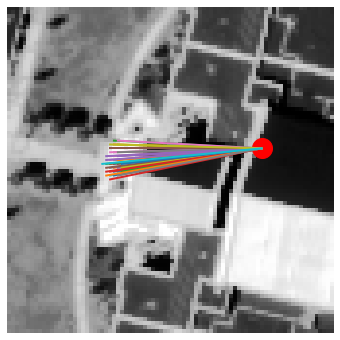

cross_attn layer 1 head 7 (epi_dist_thr=168.0)


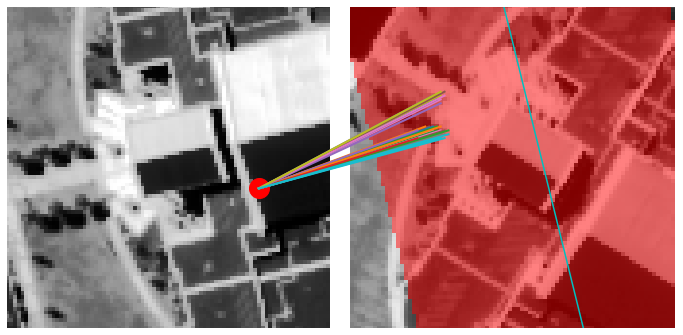

self_attn layer 2 head 7


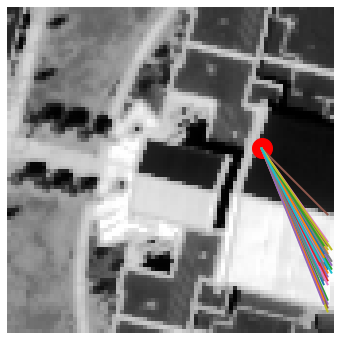

cross_attn layer 3 head 7 (epi_dist_thr=134.4)


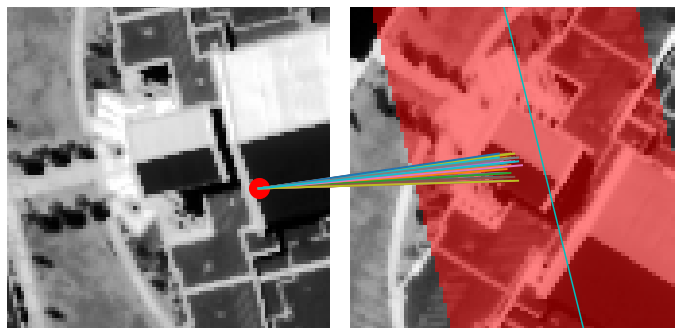

self_attn layer 4 head 7


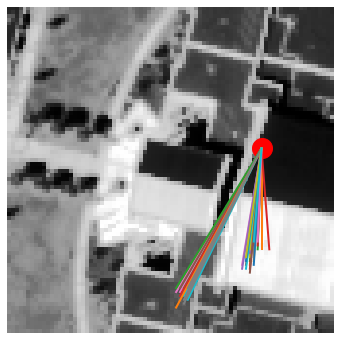

cross_attn layer 5 head 7 (epi_dist_thr=100.8)


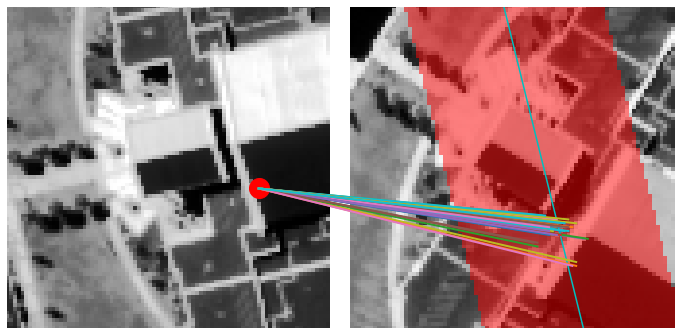

self_attn layer 6 head 7


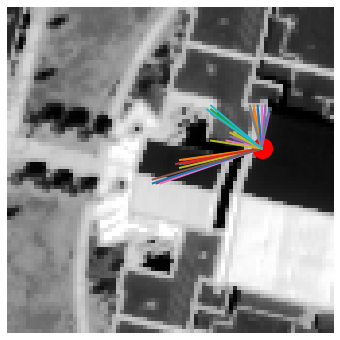

cross_attn layer 7 head 7 (epi_dist_thr=67.2)


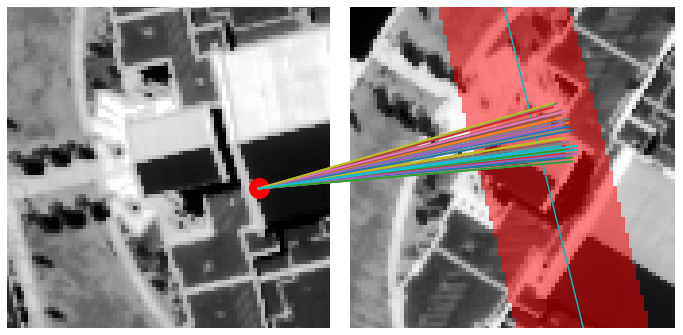

In [15]:
for head_idx in range(model_config["epimask"]["coarse"]["nhead"]):
    for key, value in attn_maps.items():
        kind = key.split(".")[-1]
        layer_num = key.split(".")[2]
        if kind == "cross_attn":
            this_attn, this_epi_thr = value[0]["attn"], value[0]["epi_dist_thr"]
            this_attn = this_attn[0, :, :, head_idx]
            attn_score = this_attn[idx, :].numpy().reshape(h1_c, w1_c)
            attn_mask = (epi_dist[0, idx, :] < this_epi_thr).cpu().numpy().reshape(h1_c, w1_c)
            print(f"cross_attn layer {layer_num} head {head_idx} (epi_dist_thr={this_epi_thr:.1f})")
            plot_cross_attn(xc, yc, left_image, right_image, attn_score, attn_mask,
                             data["F_gt"].cpu(), num_att_pts=num_att_pts)
        elif kind == "self_attn":
            this_attn = value[0]["attn"][0, head_idx, :, :]
            attn_score = this_attn[idx, :].numpy().reshape(h0_c, w0_c)
            print(f"self_attn layer {layer_num} head {head_idx}")
            plot_self_attn(xc, yc, left_image, attn_score, num_att_pts=num_att_pts)


Final coarse confidence matrix (post-softmax matching scores from `data['conf_matrix']`, after all coarse-transformer layers), overlaid with the last cross-attention layer's epipolar mask.

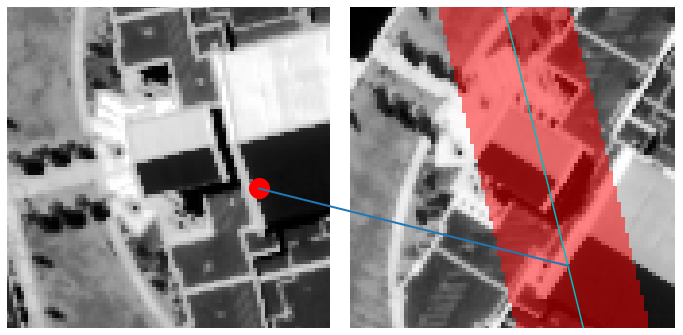

In [16]:
cross_attn_keys = [k for k in attn_maps if k.endswith("cross_attn")]
last_cross_attn_key = cross_attn_keys[-1]
this_epi_thr = attn_maps[last_cross_attn_key][0]["epi_dist_thr"]

conf_score = data["conf_matrix"].detach().cpu()[0, idx, :].numpy().reshape(h1_c, w1_c)
attn_mask = (epi_dist[0, idx, :] < this_epi_thr).cpu().numpy().reshape(h1_c, w1_c)

plot_cross_attn(xc, yc, left_image, right_image, conf_score, attn_mask, data["F_gt"].cpu(), num_att_pts=1)


## 9. Model FLOPs / params

In [17]:
class Wrapper(torch.nn.Module):
    """ptflops needs a single-tensor-input module; build the full EpiMask input dict from it."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        B, C, H, W = x.shape
        dummy = {
            "image0": torch.randn(B, 1, H, W, device=x.device),
            "image1": torch.randn(B, 1, H, W, device=x.device),
            "lat0": torch.randn(B, 1, H, W, device=x.device),
            "lon0": torch.randn(B, 1, H, W, device=x.device),
            "ht0": torch.randn(B, 1, H, W, device=x.device),
            "lat1": torch.randn(B, 1, H, W, device=x.device),
            "lon1": torch.randn(B, 1, H, W, device=x.device),
            "ht1": torch.randn(B, 1, H, W, device=x.device),
            "affine_cam0": torch.randn(B, 3, 4, device=x.device),
            "affine_cam1": torch.randn(B, 3, 4, device=x.device),
            "F_gt": torch.eye(3, device=x.device).unsqueeze(0).repeat(B, 1, 1),
        }
        return self.model(dummy)


In [18]:
from ptflops import get_model_complexity_info

# patch size actually used to train this checkpoint (was previously hardcoded to a stale
# value independent of which experiment was loaded)
patch_size = model_config["dataset"]["satdepth_img_resize"]

wrapped = Wrapper(model)
with torch.no_grad():
    flops, params = get_model_complexity_info(
        wrapped, (1, patch_size, patch_size),
        as_strings=True, print_per_layer_stat=False, verbose=False,
    )
print("FLOPs:", flops)
print("Params:", params)


FLOPs: 96.35 GMac
Params: 14.75 M
